![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_2/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller: Reconocimiento facial con K-medias y K-medoides

En este caso-taller vamos a aplicar K-medias y K-medoides para agrupar rostros de indiviudos. Utilizaremos la base de datos conocida como Caras Olivetti. Esta base contiene diez imágenes diferentes de  40 personas distintas. Para algunas personas, las imágenes se tomaron en diferentes momentos, variando la iluminación, las expresiones faciales (ojos abiertos/cerrados, sonriendo/sin sonreír) y los detalles faciales (gafas/sin gafas). Todas las imágenes fueron tomadas contra un fondo homogéneo oscuro con los sujetos en una posición frontal erguida (con tolerancia a algún movimiento lateral). Esta base viene incluida dentro de la libraría `scikit-learn` y fueron provistas por T&T Laboratories Cambridge para que la comunidad académica la utilice para la evaluación de modelos predictivos.

## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Desarrollo


### 1.Carga de datos

Los datos pueden ser bajados directamente utilizando la librería `scikit-learn`,  la función que le permite hacer esto es `fetch_olivetti_faces`.

In [5]:
#Configuración inicial del sistema 
import sys
import sklearn
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\mc-c2\scikit_learn_data


En primer lugar, se realiza la configuración inicial del entorno de trabajo mediante la importación de las principales librerías para el manejo de datos y visualización. Posteriormente, se cargó la base de datos y se asignó a una variable, lo que permite acceder a su contenido de manera organizada y reutilizarla fácilmente en los análisis y transformaciones posteriores.

### 2.  Análisis preliminar

#### 2.1. Describa los contenidos de la base de datos, tenga en cuenta que debe detallar los elementos, la dimensión de la base, y la dimensión de las imágenes. Genere una figura con una imagen de cada uno de los individuos

In [10]:
#Dimensiones de las imagenes 
print("Dimensiones de los datos:", olivetti.data.shape)
print("Dimensiones de las imágenes:", olivetti.images.shape)
print("Dimensiones de los nombres:", olivetti.target.shape)
print("Descripción de la base:", olivetti.DESCR)

Dimensiones de los datos: (400, 4096)
Dimensiones de las imágenes: (400, 64, 64)
Dimensiones de los nombres: (400,)
Descripción de la base: .. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position


En primer lugar, el componente *data* corresponde a una matriz donde cada fila representa una imagen en formato vector expresado en el número de sus píxeles. Por su parte, *images* almacena las imágenes en su formato bidimensional original, conservando su estructura visual. El elemento *target* es un vector que asigna a cada imagen una etiqueta numérica que identifica al individuo correspondiente. Finalmente, *DESCR* proporciona una descripción general del conjunto de datos. Esta organización permite trabajar tanto con la representación numérica como visual de las imágenes.

#### 2.2. Genere una figura con una imagen de cada uno de los individuos

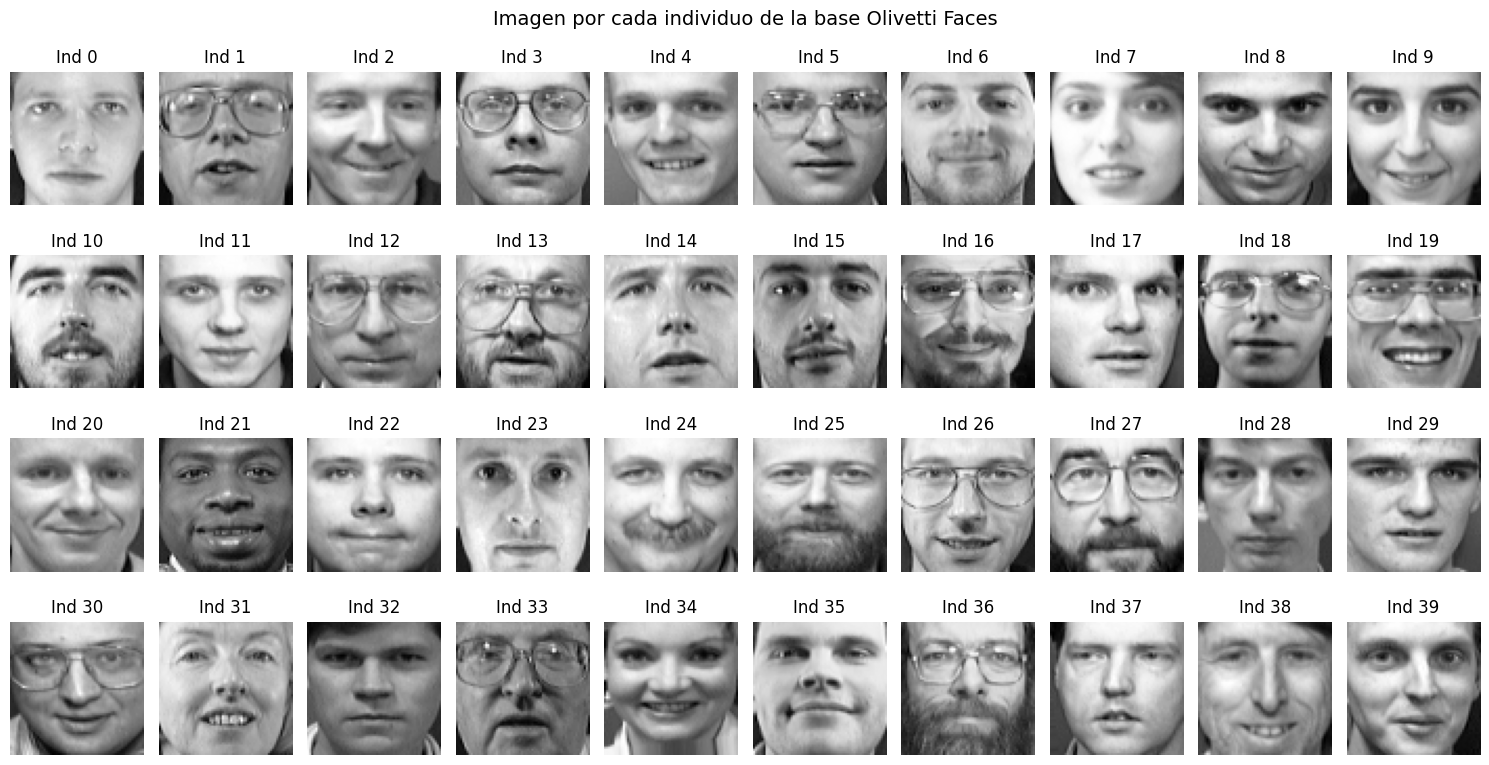

In [13]:
# Identificar los individuos únicos 
individuos = np.unique(olivetti.target)

# Crear una figura con 4 filas y 10 columnas
fig, axes = plt.subplots(4, 10, figsize=(15, 8))
axes = axes.ravel()

# Recorrer cada individuo
for i, individuo in enumerate(individuos):
    # Buscar la primera imagen asociada a ese individuo
    idx = np.where(olivetti.target == individuo)[0][0]
    
    # Mostrar la imagen
    axes[i].imshow(olivetti.images[idx], cmap='gray')
    axes[i].set_title(f'Ind {individuo}')
    axes[i].axis('off')

plt.suptitle('Imagen por cada individuo de la base Olivetti Faces', fontsize=14)
plt.tight_layout()
plt.show()

Para visualizar la composición de la base de datos, se seleccionó una imagen representativa de cada individuo a partir de las etiquetas contenidas en *target*. Posteriormente, estas imágenes se organizaron en una cuadrícula, lo que permite observar de forma general los 40 rostros incluidos en la base de datos y verificar visualmente la diversidad de individuos presentes.

#### 2.3. Transforme las imágenes en un data frame donde cada columna contiene los valores estandarizados del nivel de gris en la imagen y una columna con la etiqueta de cada imagen.

In [15]:
from sklearn.preprocessing import StandardScaler

# 1. Tomar la matriz de datos 
X = olivetti.data

# 2. Estandarizar los valores de los píxeles
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Convertir a DataFrame
df = pd.DataFrame(X_scaled)

# 4. Agregar la columna de etiquetas
df['target'] = olivetti.target

# Ver resultado
print(df.shape)
df.head()

(400, 4097)


,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,target
0,-0.499903,-0.351181,-0.302961,-0.395361,-0.137608,0.104953,0.213296,0.194894,0.171393,0.065267,...,1.663788,1.598077,1.621725,0.726428,-1.092090,-0.959562,-0.898275,-0.831520,-0.850457,0
1,0.301499,0.194640,0.185686,0.203914,0.213404,0.290404,0.361849,0.355027,0.311534,0.180529,...,-1.157252,-1.249632,-1.096954,-1.007794,-0.982783,-0.938375,-0.898275,-0.876585,-0.873362,0
2,-0.454109,-0.176519,0.079458,0.054095,0.169528,0.383129,0.361849,0.248272,0.255477,0.151713,...,-1.293754,-0.999033,-1.162729,-1.141196,-1.004644,-0.980749,-0.964353,-0.899118,-0.873362,0
3,-1.118128,-1.268161,-1.450221,-1.679522,-1.936544,-2.236356,-2.262576,-1.566562,-1.230019,-1.116165,...,1.481785,1.620859,1.753274,2.082678,2.143408,2.197309,2.295495,2.390682,2.379126,0
4,0.553368,0.587631,0.546860,0.546357,0.498602,0.568579,0.436125,0.435093,0.395618,0.382236,...,-1.134502,-1.021815,-0.965405,-0.874393,-0.851614,-0.811252,-0.766119,-0.763921,-0.758838,0


Con el objetivo de facilitar el análisis de datos, las imágenes fueron transformadas en un DataFrame, donde cada fila representa una imagen y cada columna corresponde a un píxel. Asimismo, los valores de intensidad de los píxeles fueron estandarizados para que cada variable tuviera media cero y desviación estándar uno. Finalmente, se añadió una columna adicional que contiene la etiqueta de cada imagen, lo que permite identificar el individuo correspondiente y facilita su uso en análisis posteriores.

### 3. Clasificando de forma no supervisada

En esta sección trataremos de clasificar las imágenes de los individuos de forma no supervisada. Para ello utilizaremos los algoritmos de k-medias y k-medoides. Dado que sabemos que el dataset consta de 40 personas diferentes, utilizaremos esta información para pedirle a los algoritmos encuentren k=40 clusters y examinaremos su precisión .


#### 3.1. Implemente k-medias sobre los datos estandarizados en el punto anterior. Al implementar utilice  `random_state=123` y `n_init=10`. (Esto puede tomar mucho tiempo y requerir mucho RAM, puede aprovechar los recursos de [Google Colab](https://colab.research.google.com/))

In [ ]:
from sklearn.cluster import KMeans

# Separar variables explicativas y etiquetas
X = df.drop(columns='target')
y = df['target']

# Implementar K-means
kmeans = KMeans(n_clusters=40, random_state=123, n_init=10)
kmeans.fit(X)

# Etiquetas asignadas por el algoritmo
clusters_kmeans = kmeans.labels_

# Ver las primeras asignaciones
print(clusters_kmeans[:10])

En esta etapa se implementó el algoritmo de K-means sobre los datos estandarizados, utilizando como entrada únicamente los valores de los píxeles y excluyendo la etiqueta real de cada imagen. Dado que la base contiene 40 individuos, se fijó el número de clústeres en 40 con el fin de comparar posteriormente el agrupamiento obtenido con la clasificación real. Además, se usó random_state=123 para garantizar la reproducibilidad de los resultados y n_init=10 para mejorar la estabilidad del algoritmo mediante varias inicializaciones.

#### 3.2. Evalúe la precisión del algoritmo para agrupar las imágenes de los individuos.

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones)

#### 3.3. Usando PCA reduzca la dimensión de la matriz de predictores. Retenga el numero de componentes que explican el 95% de la varianza y vuelva a utilizar k-medias para clasificar las imágenes comentado si la precisión mejoró.

In [ ]:
from sklearn.decomposition import PCA

(Utilice este espacio para describir el procedimiento, análisis y conclusiones)

#### 3.4. Utilice ahora el algoritmo por  K-medoides (use el mismo random state a los puntos anteriores), comente si mejoró la precisión total y para cada grupo de imágenes.

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones)

### 4. Número de clusters óptimo

En el punto anteriores utilizamos nuestro conocimiento previo sobre los datos para elegir el número de clusters. En este punto, verifique si 40 es realmente el número de cluster que usted elegiría según los criterios estudiados en los cuadernos teóricos. Discuta los resultados obtenidos.

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones)